# Trabajo Práctico 2 - Grupo 02

### Ensamble — Soft Voting: XLM-RoBERTa + XGBoost + Naive Bayes

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Estrategia:** Soft voting ponderado por F1-macro en Kaggle

**Modelos:**
- `xlm-roberta-base` — reentrenado con params de v8 (lr=2e-5, epochs=3, max_length=128) — peso 0.50
- `XGBoost + BoW` — cargado desde `xgb_bow_aug_baseline_v6_3.joblib` — peso 0.30
- `Naive Bayes + BoW GridSearch` — cargado desde `nb_bow_gridsearch.joblib` — peso 0.20

**Justificación del ensamble:**
El soft voting promedia las probabilidades de cada clase producidas por cada modelo. A diferencia del hard voting (mayoría de votos), aprovecha la confianza de cada predicción: si RoBERTa está 95% seguro de que una reseña es positiva, ese peso se traslada al resultado final. Los pesos son proporcionales al F1-macro obtenido en Kaggle por cada modelo (0.72765, 0.68157, 0.66461), normalizados para sumar 1. La diversidad entre los modelos es clave: RoBERTa entiende contexto semántico profundo, mientras que XGBoost y Naive Bayes capturan patrones de frecuencia de palabras — errores distintos que se compensan.

## 1. Instalación de dependencias  

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install transformers datasets accelerate
!pip install scikit-learn xgboost joblib
!pip install pandas numpy matplotlib seaborn
!python -m spacy download es_core_news_sm

Looking in indexes: https://download.pytorch.org/whl/cu124
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 10.0 MB/s e

## 2. Imports y configuración

In [2]:
import sys
sys.path.insert(0, "/kaggle/input/datasets/maylennieves/common-2")

import numpy as np
import pandas as pd
import torch
import joblib
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, classification_report

from common.data_utils import get_split, SEED
from common.preprocessing import clean_minimal, clean_classical
from common.evaluation import evaluate

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME  = "xlm-roberta-base"
MAX_LENGTH  = 128
BATCH_SIZE  = 16
NUM_EPOCHS  = 3
LR          = 2e-05
CLASS_NAMES = ["negativa", "neutra", "positiva"]

# Pesos del ensamble proporcionales al F1-macro en Kaggle
# RoBERTa: 0.72765 | XGBoost: 0.68157 | NaiveBayes: 0.66461
_scores = np.array([0.72765, 0.68157, 0.66461])
WEIGHTS = _scores / _scores.sum()
print(f"Pesos del ensamble: RoBERTa={WEIGHTS[0]:.3f} | XGB={WEIGHTS[1]:.3f} | NB={WEIGHTS[2]:.3f}")

print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Pesos del ensamble: RoBERTa=0.351 | XGB=0.329 | NB=0.320
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Carga de datos

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/maylennieves/datoss/train.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/maylennieves/datoss/test.csv")

print(f"Train: {len(train_df):,} filas | Test: {len(test_df):,} filas")
print(f"Distribución:\n{train_df['label'].value_counts().sort_index()}")

X_train_raw, X_val_raw, y_train, y_val = get_split(train_df)

# RoBERTa usa clean_minimal (preserva mayúsculas y acentos)
print("\nPreprocesando para RoBERTa (clean_minimal)...")
X_train_min = np.array([clean_minimal(t) for t in X_train_raw])
X_val_min   = np.array([clean_minimal(t) for t in X_val_raw])
X_test_min  = np.array([clean_minimal(t) for t in test_df["text"].values])

# XGBoost y NB usan clean_classical (lowercase + lemmatización + stopwords)
print("Preprocesando para XGBoost/NB (clean_classical)...")
X_train_cls = np.array([clean_classical(t) for t in X_train_raw])
X_val_cls   = np.array([clean_classical(t) for t in X_val_raw])
X_test_cls  = np.array([clean_classical(t) for t in test_df["text"].values])

print(f"\nTrain: {len(X_train_raw):,} | Val: {len(X_val_raw):,} | Test: {len(X_test_min):,}")

Train: 51,000 filas | Test: 8,500 filas
Distribución:
label
0    20400
1    10200
2    20400
Name: count, dtype: int64

Preprocesando para RoBERTa (clean_minimal)...
Preprocesando para XGBoost/NB (clean_classical)...

Train: 40,800 | Val: 10,200 | Test: 8,500


## 4. Entrenamiento de XLM-RoBERTa-base

Mismos hiperparámetros que v8 (el mejor en Kaggle con F1=0.72765).
`gradient_accumulation_steps=2` simula batch efectivo de 32 sin doblar VRAM.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ResenasDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

print("Tokenizando...")
train_dataset = ResenasDataset(X_train_min, y_train, tokenizer, MAX_LENGTH)
val_dataset   = ResenasDataset(X_val_min,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = ResenasDataset(X_test_min,  None,    tokenizer, MAX_LENGTH)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}

model_roberta = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True
).to(DEVICE)

total = sum(p.numel() for p in model_roberta.parameters())
print(f"Parámetros: {total:,}")

training_args = TrainingArguments(
    output_dir="models/roberta_ensemble",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=2,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model_roberta,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Entrenando XLM-RoBERTa-base (v8 params)...")
trainer.train()

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizando...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1914, training_loss=2.280795283701228, metrics={'train_runtime': 2607.1146, 'train_samples_per_second': 46.948, 'train_steps_per_second': 0.734, 'total_flos': 8051270582476800.0, 'train_loss': 2.280795283701228, 'epoch': 3.0})

## 5. Carga de XGBoost y Naive Bayes

In [5]:
XGB_PATH = "/kaggle/input/datasets/maylennieves/modelos-clasicos/nb_bow_gridsearch.joblib"
NB_PATH  = "/kaggle/input/datasets/maylennieves/modelos-clasicos/nb_bow_gridsearch.joblib"

pipe_xgb = joblib.load(XGB_PATH)
pipe_nb  = joblib.load(NB_PATH)

print(f"XGBoost cargado: {XGB_PATH}")
print(f"  Pipeline: {pipe_xgb.steps}")
print(f"\nNaive Bayes cargado: {NB_PATH}")
print(f"  Pipeline: {pipe_nb.steps}")

# Verificación rápida en validación
y_pred_xgb = pipe_xgb.predict(X_val_cls)
y_pred_nb  = pipe_nb.predict(X_val_cls)
f1_xgb = f1_score(y_val, y_pred_xgb, average="macro", zero_division=0)
f1_nb  = f1_score(y_val, y_pred_nb,  average="macro", zero_division=0)
print(f"\nF1-macro val local — XGBoost: {f1_xgb:.4f} | NB: {f1_nb:.4f}")

XGBoost cargado: /kaggle/input/datasets/maylennieves/modelos-clasicos/nb_bow_gridsearch.joblib
  Pipeline: [('bow', CountVectorizer(lowercase=False, max_df=0.95, max_features=30000, min_df=5,
                ngram_range=(1, 2), token_pattern='(?u)\\b\\w[\\w-]+\\b')), ('nb', MultinomialNB(alpha=2.0, fit_prior=False))]

Naive Bayes cargado: /kaggle/input/datasets/maylennieves/modelos-clasicos/nb_bow_gridsearch.joblib
  Pipeline: [('bow', CountVectorizer(lowercase=False, max_df=0.95, max_features=30000, min_df=5,
                ngram_range=(1, 2), token_pattern='(?u)\\b\\w[\\w-]+\\b')), ('nb', MultinomialNB(alpha=2.0, fit_prior=False))]

F1-macro val local — XGBoost: 0.7292 | NB: 0.7292


## 6. Soft Voting ponderado

Para cada modelo obtenemos las **probabilidades** de las 3 clases (no solo la clase predicha).
Las combinamos como promedio ponderado por el F1-macro de Kaggle de cada modelo.
La clase con mayor probabilidad promedio es la predicción final.

In [6]:
def get_roberta_probs(dataset):
    """Extrae probabilidades de RoBERTa via softmax sobre logits."""
    output = trainer.predict(dataset)
    logits = output.predictions
    exp    = np.exp(logits - logits.max(axis=1, keepdims=True))
    return exp / exp.sum(axis=1, keepdims=True)

print("Obteniendo probabilidades de cada modelo en validación...")

# RoBERTa
probs_roberta_val = get_roberta_probs(val_dataset)

# XGBoost — predict_proba devuelve [n_samples, 3]
probs_xgb_val = pipe_xgb.predict_proba(X_val_cls)

# Naive Bayes — ídem
probs_nb_val  = pipe_nb.predict_proba(X_val_cls)

# Soft voting ponderado
probs_ensemble_val = (
    WEIGHTS[0] * probs_roberta_val +
    WEIGHTS[1] * probs_xgb_val    +
    WEIGHTS[2] * probs_nb_val
)
y_pred_ensemble_val = np.argmax(probs_ensemble_val, axis=1)

# Comparación de modelos individuales vs ensamble
probs_roberta_val_pred = np.argmax(probs_roberta_val, axis=1)
f1_roberta  = f1_score(y_val, probs_roberta_val_pred, average="macro", zero_division=0)
f1_xgb_     = f1_score(y_val, pipe_xgb.predict(X_val_cls), average="macro", zero_division=0)
f1_nb_      = f1_score(y_val, pipe_nb.predict(X_val_cls),  average="macro", zero_division=0)
f1_ensemble = f1_score(y_val, y_pred_ensemble_val,         average="macro", zero_division=0)

print(f"\n=== F1-macro en validación local ===")
print(f"  XLM-RoBERTa-base: {f1_roberta:.4f}")
print(f"  XGBoost + BoW:    {f1_xgb_:.4f}")
print(f"  Naive Bayes + BoW:{f1_nb_:.4f}")
print(f"  Ensamble (soft):  {f1_ensemble:.4f}  ← objetivo")

Obteniendo probabilidades de cada modelo en validación...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



=== F1-macro en validación local ===
  XLM-RoBERTa-base: 0.7212
  XGBoost + BoW:    0.7292
  Naive Bayes + BoW:0.7292
  Ensamble (soft):  0.7488  ← objetivo


## 7. Evaluación detallada del ensamble

In [7]:
evaluate(
    "ensamble_soft_voting_roberta_xgb_nb",
    y_val,
    y_pred_ensemble_val,
    hyperparams={
        "modelos":  "xlm-roberta-base + xgb_bow + nb_bow",
        "pesos":    f"roberta={WEIGHTS[0]:.3f} xgb={WEIGHTS[1]:.3f} nb={WEIGHTS[2]:.3f}",
        "estrategia": "soft_voting_ponderado_f1_kaggle",
        "dataset":  "original_51k",
    }
)


=== ensamble_soft_voting_roberta_xgb_nb ===
Hiperparámetros: {'modelos': 'xlm-roberta-base + xgb_bow + nb_bow', 'pesos': 'roberta=0.351 xgb=0.329 nb=0.320', 'estrategia': 'soft_voting_ponderado_f1_kaggle', 'dataset': 'original_51k'}

F1-macro:  0.7488
Precision: 0.7473
Recall:    0.7514
Accuracy:  0.7825

              precision    recall  f1-score   support

    negativa     0.8322    0.8049    0.8183      4080
      neutra     0.5392    0.5961    0.5662      2040
    positiva     0.8705    0.8532    0.8617      4080

    accuracy                         0.7825     10200
   macro avg     0.7473    0.7514    0.7488     10200
weighted avg     0.7889    0.7825    0.7853     10200

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3284     642       154
neutra         460    1216       364
positiva       202     397      3481


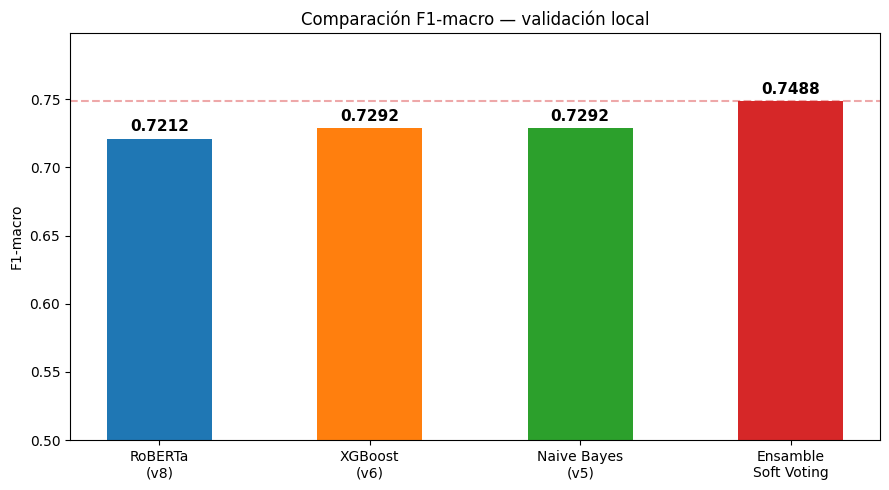

In [8]:
import matplotlib.pyplot as plt

modelos  = ["RoBERTa\n(v8)", "XGBoost\n(v6)", "Naive Bayes\n(v5)", "Ensamble\nSoft Voting"]
f1s      = [f1_roberta, f1_xgb_, f1_nb_, f1_ensemble]
colores  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(modelos, f1s, color=colores, width=0.5)
for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{f1:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0.5, min(1.0, max(f1s) + 0.05))
ax.set_ylabel("F1-macro")
ax.set_title("Comparación F1-macro — validación local")
ax.axhline(f1_ensemble, color="#d62728", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Submission a Kaggle

In [9]:
Path("submissions").mkdir(exist_ok=True)

print("Obteniendo probabilidades sobre test...")
probs_roberta_test = get_roberta_probs(test_dataset)
probs_xgb_test     = pipe_xgb.predict_proba(X_test_cls)
probs_nb_test      = pipe_nb.predict_proba(X_test_cls)

probs_ensemble_test = (
    WEIGHTS[0] * probs_roberta_test +
    WEIGHTS[1] * probs_xgb_test     +
    WEIGHTS[2] * probs_nb_test
)
y_test_pred = np.argmax(probs_ensemble_test, axis=1)

FNAME = "submissions/submission_ensamble_soft_roberta_xgb_nb.csv"
sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sub.to_csv(FNAME, index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: {FNAME}  ({len(sub):,} predicciones)")
print(f"Distribución: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")
print(f"\nF1-macro ensamble (val local): {f1_ensemble:.4f}")

Obteniendo probabilidades sobre test...


Guardado: submissions/submission_ensamble_soft_roberta_xgb_nb.csv  (8,500 predicciones)
Distribución: clase 0: 39.6%, clase 1: 21.0%, clase 2: 39.4%

F1-macro ensamble (val local): 0.7488
